<a href="https://colab.research.google.com/github/SkAmeen18/Long_Term_Decrease_in_Earth_s_Rotational_Speed/blob/main/LOD_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Monthly LOD / AAM / cryosphere / climate dataset (1962 - present)


## Step 0 - Write the build script

In [2]:
%%writefile build_lod_dataset.py
#!/usr/bin/env python3

from __future__ import annotations

import argparse
import hashlib
import json
import math
import shutil
import sys
import tempfile
import urllib.request
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

# ----------------------------------------------------------------------------
# Constants (document any change in the paper's Methods)
# ----------------------------------------------------------------------------
LOD0_MS = 86_400_000.0          # nominal day, ms
C_EARTH = 8.04e37               # axial moment of inertia of the whole Earth, kg m^2 (approx.)
R_E = 6.371e6                   # mean Earth radius, m
GT_TO_KG = 1.0e12
SRC_LAT_DEG = {"GRN": 72.0, "ANT": -80.0}   # representative latitude of the mass-loss centroid
MIN_DAYS = 20                   # minimum daily values for a valid monthly mean
# Approximate short-period zonal-tide periods (days): Mm', Mm, Msf, Mf, Mf-, Mtm.
# The 18.6-yr nodal and 9.3-yr terms are NOT fitted by default: a free fit cannot separate them from real
# decadal LOD variability (it absorbed up to +/-0.6 ms of genuine signal in testing). Supply them from the
# IERS Conventions (2010) Ch. 8 zonal-tide model (RG_ZONT2) via --tide-file.
TIDE_PERIODS_DAYS = [31.81, 27.55, 14.77, 13.66, 13.63, 9.13]
NODAL_PERIODS_DAYS = [6798.38, 3399.19]

URLS = {
    "c04": "https://hpiers.obspm.fr/iers/eop/eopc04/eopc04.1962-now",
    "co2": "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv",
    "gistemp": "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv",
}
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


# ----------------------------------------------------------------------------
# Utilities
# ----------------------------------------------------------------------------
def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def fetch(url: str, dest: Path) -> Path:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        print(f"[skip] {dest} already exists")
        return dest
    print(f"[download] {url} -> {dest}")
    req = urllib.request.Request(url, headers={"User-Agent": "lod-dataset-builder/1.0"})
    with urllib.request.urlopen(req, timeout=180) as r, open(dest, "wb") as f:
        f.write(r.read())
    return dest


def monthly(s: pd.Series, min_days: int = MIN_DAYS) -> pd.Series:
    """Monthly mean (index = first of month); NaN if fewer than min_days valid daily values."""
    g = s.dropna().resample("MS")
    return g.mean().where(g.count() >= min_days)


def mjd_to_date(mjd) -> pd.DatetimeIndex:
    return pd.Timestamp("1858-11-17") + pd.to_timedelta(np.floor(np.asarray(mjd, float)), unit="D")


# ----------------------------------------------------------------------------
# Parsers
# ----------------------------------------------------------------------------
def parse_c04(path: Path) -> pd.DataFrame:
    """IERS EOP C04 daily file -> DataFrame[date index; lod_ms, lod_err_ms].

    20 C04 layout (header-driven):  YR MM DD HH MJD x y UT1-UTC dX dY xrt yrt LOD(s) ... LOD_Er(s)
    Column positions of MJD and LOD are read from the '# ... MJD ... LOD(s)' header line, and the LOD
    uncertainty is the LAST column. If no such header exists, the legacy 14 C04 layout is assumed:
    YR MM DD MJD x y UT1-UTC LOD dX dY x_err y_err UT1_err LOD_err.  LOD is in SECONDS in the file."""
    mjd_i, lod_i, header = 3, 7, False
    rows = []
    with open(path, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            if line.lstrip().startswith("#"):
                toks = line.lstrip("# \t").split()
                lod_names = [k for k, x in enumerate(toks) if x.startswith("LOD(")]
                if "MJD" in toks and lod_names:
                    mjd_i, lod_i, header = toks.index("MJD"), lod_names[0], True
                continue
            t = line.split()
            if len(t) <= lod_i:
                continue
            try:
                y, m, d = int(t[0]), int(t[1]), int(t[2])
                mjd, lod = float(t[mjd_i]), float(t[lod_i])
                err = float(t[-1]) if header else (float(t[13]) if len(t) > 13 else np.nan)
            except ValueError:
                continue
            if not (1900 <= y <= 2100 and 1 <= m <= 12 and 1 <= d <= 31):
                continue
            rows.append((y, m, d, mjd, lod, err))
    if not rows:
        raise ValueError(f"No data rows recognised in {path}; check the file layout.")
    df = pd.DataFrame(rows, columns=["y", "m", "d", "mjd", "lod_s", "err_s"])
    if df["lod_s"].abs().median() > 0.1:
        raise ValueError("C04 LOD median > 0.1 s: the LOD column was mis-identified. Check the file layout.")
    df["date"] = pd.to_datetime(dict(year=df.y, month=df.m, day=df.d))
    bad = int((mjd_to_date(df.mjd) != df["date"].values).sum())
    if bad:
        raise ValueError(f"{bad} rows where MJD and calendar date disagree: wrong column layout?")
    df = df.drop_duplicates("date").set_index("date").sort_index()
    return pd.DataFrame({"lod_ms": df["lod_s"] * 1e3, "lod_err_ms": df["err_s"] * 1e3})


def parse_aam(path: Path, datecols, mjdcol, valcol, units: str) -> pd.Series:
    """Generic AAM reader (whitespace/comma separated; '#' comments). Returns daily LOD_AAM in ms
    (sub-daily samples are averaged per day). units='chi3' -> LOD = LOD0*chi3 ; units='ms' -> used as is.
    valcol may be a list of 0-based columns that are SUMMED (e.g. z mass term + z motion term)."""
    valcols = [valcol] if isinstance(valcol, int) else list(valcol)
    dates, vals = [], []
    with open(path, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            s = line.strip()
            if not s or s[0] in "#%!" or s[0].isalpha():
                continue
            t = s.replace(",", " ").split()
            try:
                v = sum(float(t[c]) for c in valcols)
                if mjdcol is not None:
                    dt = mjd_to_date([float(t[mjdcol])])[0]
                else:
                    y, m, d = (int(float(t[c])) for c in datecols)
                    dt = pd.Timestamp(year=y, month=m, day=d)
            except (ValueError, IndexError):
                continue
            dates.append(dt.normalize())
            vals.append(v)
    if not vals:
        raise ValueError(f"No AAM rows parsed from {path}; check --aam-* column options.")
    s = pd.Series(vals, index=pd.DatetimeIndex(dates)).groupby(level=0).mean().sort_index()
    return s * LOD0_MS if units == "chi3" else s


ESMGFZ = {"AAM": ("v1.0", "03h"), "OAM": ("v1.0", "03h"), "HAM": ("v1.2", "24h")}


def download_esmgfz(component: str, raw_dir: Path, first_year: int = 1976, last_year: int | None = None) -> Path:
    """Download yearly ESMGFZ effective-angular-momentum files (component = AAM, OAM or HAM) and concatenate them
    into raw_dir/<comp>_esmgfz_all.asc. Row layout: YYYY MM DD HH MJD, then 6 values
    (x,y,z mass term; x,y,z motion term) -> axial chi3 = 0-based columns 7 + 10."""
    ver, res = ESMGFZ[component]
    base = ("https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_{c}/ESMGFZ_{c}_{v}_{r}_{{y}}.asc"
            .format(c=component, v=ver, r=res))
    last_year = last_year or datetime.now(timezone.utc).year
    parts, missing = [], []
    for y in range(first_year, last_year + 1):
        try:
            parts.append(fetch(base.format(y=y), raw_dir / f"{component.lower()}_parts" / f"ESMGFZ_{component}_{ver}_{res}_{y}.asc"))
        except Exception as e:  # noqa: BLE001
            missing.append((y, repr(e)))
    if len(parts) < 40:
        raise RuntimeError(f"Only {len(parts)} yearly {component} files downloaded; errors: {missing[:3]}. "
                           "Download them manually from the IERS GGFC / ESMGFZ repository.")
    out = raw_dir / f"{component.lower()}_esmgfz_all.asc"
    with open(out, "w") as fo:
        for pth in parts:
            with open(pth, errors="replace") as fi:
                fo.write(fi.read())
    if missing:
        print("WARNING missing years:", missing)
    return out


def download_esmgfz_aam(raw_dir: Path, first_year: int = 1976, last_year: int | None = None) -> Path:
    return download_esmgfz("AAM", raw_dir, first_year, last_year)


def parse_co2(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, comment="#")
    df.columns = [c.strip() for c in df.columns]
    for c in ("average", "deseasonalized"):
        df.loc[df[c] <= 0, c] = np.nan          # NOAA missing-value flags are -99.99 / -9.99
    df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
    return df.set_index("date")[["average", "deseasonalized"]].rename(
        columns={"average": "CO2_ppm", "deseasonalized": "CO2_deseason_ppm"})


def parse_gistemp(path: Path) -> pd.Series:
    df = pd.read_csv(path, skiprows=1, na_values=["***", "****", "*****"])
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])
    long = df.melt(id_vars="Year", value_vars=MONTHS, var_name="mon", value_name="v")
    long["month"] = long["mon"].map({m: i + 1 for i, m in enumerate(MONTHS)})
    long["v"] = pd.to_numeric(long["v"], errors="coerce")
    long["date"] = pd.to_datetime(dict(year=long["Year"].astype(int), month=long["month"], day=1))
    return long.set_index("date")["v"].sort_index().rename("Temp_anomaly_C")


def parse_grace(path: Path) -> pd.DataFrame:
    """JPL GRACE Tellus mascon ice-sheet time series: decimal-year, mass anomaly (Gt), uncertainty (Gt).
    Header lines (HDR/#) skipped. Several solutions in one month are averaged; gaps stay NaN."""
    rows = []
    with open(path, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            s = line.strip()
            if not s or s.startswith(("HDR", "#")):
                continue
            t = s.replace(",", " ").split()
            try:
                dy, mass = float(t[0]), float(t[1])
                unc = float(t[2]) if len(t) > 2 else np.nan
            except (ValueError, IndexError):
                continue
            if not 2000 < dy < 2100:
                continue
            yr = int(dy)
            ndays = 366 if (yr % 4 == 0 and (yr % 100 != 0 or yr % 400 == 0)) else 365
            ts = pd.Timestamp(year=yr, month=1, day=1) + pd.Timedelta(days=(dy - yr) * ndays)
            rows.append((ts.to_period("M").to_timestamp(), mass, unc))
    if not rows:
        raise ValueError(f"No GRACE rows parsed from {path}.")
    df = pd.DataFrame(rows, columns=["date", "mass", "unc"]).groupby("date").mean()
    return df


# ----------------------------------------------------------------------------
# Physics
# ----------------------------------------------------------------------------
def harmonic_tide(daily: pd.Series, include_nodal: bool = False) -> pd.Series:
    """Least-squares fit of the zonal-tide periods to the daily LOD (no intercept in the returned tide)."""
    t = (daily.index - pd.Timestamp("2000-01-01")).days.values.astype(float)
    cols = [np.ones_like(t)]
    for p in TIDE_PERIODS_DAYS + (NODAL_PERIODS_DAYS if include_nodal else []):
        w = 2 * np.pi / p
        cols += [np.cos(w * t), np.sin(w * t)]
    A = np.column_stack(cols)
    ok = np.isfinite(daily.values)
    coef, *_ = np.linalg.lstsq(A[ok], daily.values[ok], rcond=None)
    return pd.Series(A[:, 1:] @ coef[1:], index=daily.index)


# ----------------------------------------------------------------------------
# IERS Conventions (2010) zonal-tide model - Python port of RG_ZONT2.F
# Derived work: the multiplier and coefficient tables are READ AT RUN TIME from the unmodified IERS file RG_ZONT2.F
# (R. S. Gross; revised B. E. Stetzler; IERS Conventions Center). This is NOT IERS software and is not endorsed by the
# IERS. Differences from the original: Python/numpy, vectorised over dates, and the fundamental arguments (FUNDARG.F,
# not supplied) re-implemented from the IERS 2003 Delaunay polynomial expressions. The port reproduces the test case in
# the header of RG_ZONT2.F to ~1e-15 relative (checked on every run). When publishing, state that the IERS Conventions
# (2010) RG_ZONT2 zonal-tide model (software revision of 20 Dec 2011) was used.
# ----------------------------------------------------------------------------
import re as _re


def _fortran_block(src: str, name: str, ncol: int) -> np.ndarray:
    vals = []
    for m in _re.finditer(r"DATA\s*\(\s*\(\s*" + name + r"\(I,J\).*?/(.*?)/", src, _re.S):
        body = "\n".join(l.split(":", 1)[1] if ":" in l[:7] else "" for l in m.group(1).splitlines())
        vals += [float(x.replace("D", "e").replace("d", "e"))
                 for x in _re.findall(r"[-+]?\d+\.?\d*(?:[dD][-+]?\d+)?", body)]
    arr = np.array(vals)
    if arr.size != 62 * ncol:
        raise ValueError(f"Expected 62 x {ncol} values for {name} in RG_ZONT2.F, found {arr.size}. Wrong or modified file?")
    return arr.reshape(-1, ncol)


def load_rg_zont2_tables(path: str):
    src = Path(path).read_text(errors="replace")
    if "SUBROUTINE RG_ZONT2" not in src:
        raise ValueError(f"{path} does not look like RG_ZONT2.F")
    return _fortran_block(src, "NFUND", 5).astype(int), _fortran_block(src, "TIDE", 6)


def _fundarg(T: np.ndarray):
    as2r, turn = 4.848136811095359935899141e-6, 1296000.0
    l = 485868.249036 + T * (1717915923.2178 + T * (31.8792 + T * (0.051635 + T * (-0.00024470))))
    lp = 1287104.79305 + T * (129596581.0481 + T * (-0.5532 + T * (0.000136 + T * (-0.00001149))))
    f = 335779.526232 + T * (1739527262.8478 + T * (-12.7512 + T * (-0.001037 + T * 0.00000417)))
    d = 1072260.70369 + T * (1602961601.2090 + T * (-6.3706 + T * (0.006593 + T * (-0.00003169))))
    om = 450160.398036 + T * (-6962890.5431 + T * (7.4722 + T * (0.007702 + T * (-0.00005939))))
    return [np.fmod(x, turn) * as2r for x in (l, lp, f, d, om)]


def zonal_tide_iers2010_py(T, tables):
    """Vectorised port of RG_ZONT2: T = Julian centuries since J2000 -> (DUT s, DLOD s/day, DOMEGA rad/s)."""
    nf, td = tables
    T = np.atleast_1d(np.asarray(T, float))
    L, LP, F, D, OM = _fundarg(T)
    arg = np.mod(np.outer(L, nf[:, 0]) + np.outer(LP, nf[:, 1]) + np.outer(F, nf[:, 2])
                 + np.outer(D, nf[:, 3]) + np.outer(OM, nf[:, 4]), 2 * np.pi)
    s, c = np.sin(arg), np.cos(arg)
    return ((s @ td[:, 0] + c @ td[:, 1]) * 1e-4,
            (c @ td[:, 2] + s @ td[:, 3]) * 1e-5,
            (c @ td[:, 4] + s @ td[:, 5]) * 1e-14)


def check_rg_zont2_test_case(tables) -> None:
    got = tuple(float(x[0]) for x in zonal_tide_iers2010_py(0.07995893223819302, tables))
    exp = (7.983287678576557467e-02, 5.035331113978199288e-05, -4.249711616463017e-14)
    for g, r, nm in zip(got, exp, ("DUT", "DLOD", "DOMEGA")):
        if abs(g - r) > 1e-12 * abs(r):
            raise ValueError(f"RG_ZONT2 test case failed for {nm}: {g!r} vs {r!r}")


def rg_zont2_tide(dates: pd.DatetimeIndex, path: str) -> pd.Series:
    """Zonal-tide excess LOD (ms) at 0h UTC of each date (62 terms, 5 days to 18.6 years). The UTC/TT offset
    (~1 minute) is ignored, as the routine itself allows (its Note 1)."""
    tables = load_rg_zont2_tables(path)
    check_rg_zont2_test_case(tables)
    mjd = (dates - pd.Timestamp("1858-11-17")).days.values.astype(float)
    _, dlod, _ = zonal_tide_iers2010_py((mjd - 51544.5) / 36525.0, tables)
    tide_ms = dlod * 1e3
    amp = float(np.max(np.abs(tide_ms)))
    if not 0.05 < amp < 3.0:
        raise ValueError(f"Zonal tide peak {amp:.3f} ms outside the plausible range.")
    return pd.Series(tide_ms, index=dates)


def periodic_amplitude(s: pd.Series, periods=(13.66, 27.55)) -> dict:
    t = (s.index - pd.Timestamp("2000-01-01")).days.values.astype(float)
    cols = [np.ones_like(t), t]
    for per in periods:
        w = 2 * np.pi / per
        cols += [np.cos(w * t), np.sin(w * t)]
    A = np.column_stack(cols)
    coef, *_ = np.linalg.lstsq(A, s.values, rcond=None)
    return {per: float(np.hypot(coef[2 + 2 * k], coef[3 + 2 * k])) for k, per in enumerate(periods)}


def delta_izz(mass_anom_gt: pd.Series, lat_deg: float) -> pd.Series:
    """dIzz (kg m^2) for an ice-sheet mass anomaly (Gt, negative = loss) redistributed to a uniform ocean layer."""
    lost_kg = -mass_anom_gt * GT_TO_KG
    return lost_kg * R_E ** 2 * (2.0 / 3.0 - math.cos(math.radians(lat_deg)) ** 2)


def grace_flag(date: pd.Timestamp, has_value: bool) -> str:
    if date < pd.Timestamp("2002-04-01"):
        return "PRE_GRACE"
    if pd.Timestamp("2017-07-01") <= date <= pd.Timestamp("2018-05-01"):
        return "GRACE_GAP" if not has_value else "GRACE_FO"
    if not has_value:
        return "MISSING_MONTH"
    return "GRACE" if date <= pd.Timestamp("2017-06-01") else "GRACE_FO"


def synthetic_score(s: pd.Series) -> float:
    """Fraction of variance explained by quadratic trend + annual + semi-annual terms.
    Real geophysical series always keep irregular variability; a value > 0.9999 means the series
    is (almost) a perfect smooth curve, i.e. generated rather than observed."""
    s = s.dropna()
    if len(s) < 36:
        return float("nan")
    t = (s.index.year + (s.index.month - 1) / 12.0).values.astype(float)
    t = t - t.mean()
    cols = [np.ones_like(t), t, t ** 2]
    for per in (1.0, 0.5):
        w = 2 * np.pi / per
        cols += [np.cos(w * t), np.sin(w * t)]
    A = np.column_stack(cols)
    coef, *_ = np.linalg.lstsq(A, s.values, rcond=None)
    res = s.values - A @ coef
    return float(1.0 - res.var() / s.values.var())


def provenance_guard(m: pd.DataFrame, allow: bool) -> None:
    flagged = {}
    for c in ("LOD_obs_ms", "LOD_AAM_ms", "GRN_mass_Gt", "ANT_mass_Gt"):
        sc = synthetic_score(m[c])
        if sc == sc and sc > 0.9999:
            flagged[c] = round(sc, 8)
    if flagged and not allow:
        raise ValueError(
            f"Provenance guard: {flagged} look generated (smooth trend + seasonal cycle only), not observed. "
            "Use the original downloaded files. (--allow-synthetic overrides, for tests only.)")


# ----------------------------------------------------------------------------
# Build
# ----------------------------------------------------------------------------
def build(a) -> pd.DataFrame:
    inputs = {}
    c04 = parse_c04(Path(a.c04)); inputs["c04"] = a.c04
    lod = c04["lod_ms"]

    if getattr(a, "rg_zont2", None):
        Path(a.out).parent.mkdir(parents=True, exist_ok=True)
        tide = rg_zont2_tide(lod.index, a.rg_zont2)
        tide.rename("tide_ms").to_csv(Path(a.out).with_suffix(".zonal_tide.csv"))
        inputs["rg_zont2"] = a.rg_zont2
        tide_method = ("IERS Conventions 2010 RG_ZONT2 zonal-tide model (62 terms, 5 d to 18.6 yr; Python port, "
                       "official test case reproduced)")
    elif a.tide_file:
        tf = pd.read_csv(a.tide_file, parse_dates=[0], index_col=0).iloc[:, 0]
        tide = tf.reindex(lod.index)
        if tide.isna().any():
            raise ValueError("--tide-file does not cover every day of the C04 series.")
        tide_method = "external (IERS zonal tide model)"; inputs["tide_file"] = a.tide_file
    else:
        tide = harmonic_tide(lod, include_nodal=getattr(a, "fit_nodal", False))
        tide_method = ("short-period harmonic fit only (Mm, Msf, Mf ...); 18.6-yr nodal tide NOT removed - "
                       "supply IERS RG_ZONT2 via --tide-file for publication")
    detided = lod - tide
    if len(lod.dropna()) > 1000:
        before, after = periodic_amplitude(lod.dropna()), periodic_amplitude(detided.dropna())
        print("Tide check (amplitude of fortnightly 13.66 d / monthly 27.55 d terms, ms): "
              + ", ".join(f"{k} d: {before[k]:.3f} -> {after[k]:.3f}" for k in before))

    m = pd.DataFrame({
        "LOD_obs_ms": monthly(lod),
        "LOD_obs_err_ms": monthly(c04["lod_err_ms"]),
        "N_days": lod.dropna().resample("MS").count(),
        "LOD_tide_ms": monthly(tide),
        "LOD_detided_ms": monthly(detided),
    })
    last = m["LOD_obs_ms"].last_valid_index()
    m = m.loc[:last]
    idx = m.index

    # AAM -> LOD units, mean removed over the overlap with LOD (AAM is an anomaly; LOD keeps its offset)
    aam_offset = np.nan
    if a.aam_file:
        mjdcol = a.aam_mjdcol
        datecols = None if mjdcol is not None else [int(x) for x in a.aam_datecols.split(",")]
        aam = monthly(parse_aam(Path(a.aam_file), datecols, mjdcol,
                                [int(x) for x in str(a.aam_valcol).split(",")], a.aam_units)).reindex(idx)
        both = aam.notna() & m["LOD_detided_ms"].notna()
        aam_offset = float(aam[both].mean())
        m["LOD_AAM_ms"] = aam - aam_offset
        inputs["aam"] = a.aam_file
    else:
        m["LOD_AAM_ms"] = np.nan
    m["LOD_residual_ms"] = m["LOD_detided_ms"] - m["LOD_AAM_ms"]

    # Optional oceanic (OAM) and hydrological (HAM) angular momentum, same file layout as AAM
    for comp, path in (("OAM", getattr(a, "oam_file", None)), ("HAM", getattr(a, "ham_file", None))):
        if path:
            mjdcol = a.aam_mjdcol
            datecols = None if mjdcol is not None else [int(x) for x in a.aam_datecols.split(",")]
            ser = monthly(parse_aam(Path(path), datecols, mjdcol,
                                    [int(x) for x in str(a.aam_valcol).split(",")], a.aam_units)).reindex(idx)
            if comp == "HAM":
                ser = ser.where(ser.index >= pd.Timestamp(getattr(a, "ham_start", "1982-01-01")))
            both = ser.notna() & m["LOD_detided_ms"].notna()
            m[f"LOD_{comp}_ms"] = ser - float(ser[both].mean())
            inputs[comp.lower()] = path
        else:
            m[f"LOD_{comp}_ms"] = np.nan
    m["LOD_residual_AOH_ms"] = m["LOD_detided_ms"] - m["LOD_AAM_ms"] - m["LOD_OAM_ms"] - m["LOD_HAM_ms"]

    # CO2 and temperature
    if a.co2:
        co2 = parse_co2(Path(a.co2)).reindex(idx); inputs["co2"] = a.co2
        m["CO2_ppm"], m["CO2_deseason_ppm"] = co2["CO2_ppm"], co2["CO2_deseason_ppm"]
    else:
        m["CO2_ppm"] = np.nan; m["CO2_deseason_ppm"] = np.nan
    if a.gistemp:
        m["Temp_anomaly_C"] = parse_gistemp(Path(a.gistemp)).reindex(idx); inputs["gistemp"] = a.gistemp
    else:
        m["Temp_anomaly_C"] = np.nan

    # GRACE / GRACE-FO
    izz = {}
    for key, path in (("GRN", a.grn), ("ANT", a.ant)):
        if path:
            g = parse_grace(Path(path)).reindex(idx); inputs[key.lower()] = path
            m[f"{key}_mass_Gt"], m[f"{key}_mass_unc_Gt"] = g["mass"], g["unc"]
            izz[key] = delta_izz(g["mass"], SRC_LAT_DEG[key])
        else:
            m[f"{key}_mass_Gt"] = np.nan; m[f"{key}_mass_unc_Gt"] = np.nan
    m["GRACE_mass_total_Gt"] = m["GRN_mass_Gt"] + m["ANT_mass_Gt"]       # NaN if either is NaN
    m["Delta_Izz_kgm2"] = (izz["GRN"] + izz["ANT"]) if len(izz) == 2 else np.nan
    m["LOD_cryo_ms"] = LOD0_MS * m["Delta_Izz_kgm2"] / C_EARTH
    if a.grn and a.ant:
        m["GRACE_flag"] = [grace_flag(d, bool(pd.notna(v))) for d, v in zip(idx, m["GRACE_mass_total_Gt"])]
    else:
        m["GRACE_flag"] = ["PRE_GRACE" if d < pd.Timestamp("2002-04-01") else "NOT_LOADED" for d in idx]
    provenance_guard(m, getattr(a, "allow_synthetic", False))

    m.insert(0, "Month", idx.month); m.insert(0, "Year", idx.year)
    m.insert(0, "Date", idx.strftime("%Y-%m-%d"))
    m = m.reset_index(drop=True)

    cols = ["Date", "Year", "Month", "LOD_obs_ms", "LOD_obs_err_ms", "N_days", "LOD_tide_ms",
            "LOD_detided_ms", "LOD_AAM_ms", "LOD_OAM_ms", "LOD_HAM_ms", "LOD_residual_ms",
            "LOD_residual_AOH_ms", "CO2_ppm", "CO2_deseason_ppm",
            "Temp_anomaly_C", "GRN_mass_Gt", "GRN_mass_unc_Gt", "ANT_mass_Gt", "ANT_mass_unc_Gt",
            "GRACE_mass_total_Gt", "Delta_Izz_kgm2", "LOD_cryo_ms", "GRACE_flag"]
    m = m[cols]

    out = Path(a.out); out.parent.mkdir(parents=True, exist_ok=True)
    m.to_csv(out, index=False, na_rep="NaN", float_format="%.6g")

    manifest = {
        "built_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "output": str(out), "output_sha256": sha256(out), "rows": len(m),
        "date_range": [m["Date"].iloc[0], m["Date"].iloc[-1]],
        "inputs": {k: {"path": v, "sha256": sha256(Path(v))} for k, v in inputs.items()},
        "constants": {"LOD0_ms": LOD0_MS, "C_kgm2": C_EARTH, "R_E_m": R_E, "source_lat_deg": SRC_LAT_DEG,
                      "min_days_per_month": MIN_DAYS},
        "tide_method": tide_method, "ham_start": getattr(a, "ham_start", "1982-01-01"), "aam_offset_removed_ms": None if np.isnan(aam_offset) else aam_offset,
        "pandas": pd.__version__, "numpy": np.__version__,
    }
    (out.with_suffix(".manifest.json")).write_text(json.dumps(manifest, indent=2))
    qc_report(m, tide_method)
    return m


def qc_report(m: pd.DataFrame, tide_method: str) -> None:
    print("\n=== QC REPORT ===")
    print(f"rows: {len(m)}  range: {m.Date.iloc[0]} .. {m.Date.iloc[-1]}  tide: {tide_method}")
    for c in ["LOD_obs_ms", "LOD_AAM_ms", "LOD_OAM_ms", "LOD_HAM_ms", "LOD_residual_ms", "LOD_residual_AOH_ms", "CO2_ppm", "Temp_anomaly_C",
              "GRACE_mass_total_Gt", "LOD_cryo_ms"]:
        s = m[c]
        print(f"{c:22s} valid={s.notna().sum():4d}  min={s.min():10.4g}  max={s.max():10.4g}  mean={s.mean():10.4g}")
    print("GRACE_flag counts:", m["GRACE_flag"].value_counts().to_dict())
    print("Provenance guard: passed (series show irregular, non-generated variability)")
    if m["GRACE_mass_total_Gt"].notna().any():
        pre = m.loc[m.GRACE_flag == "PRE_GRACE", "GRACE_mass_total_Gt"].notna().sum()
        assert pre == 0, "GRACE values found before April 2002"
    assert m["Date"].is_unique and m["Date"].is_monotonic_increasing
    print("structural checks passed")


# ----------------------------------------------------------------------------
# Self-test (synthetic fixtures live in a temp dir and are deleted; they are NOT data)
# ----------------------------------------------------------------------------
def selftest() -> None:
    # 1. physics unit check: 1000 Gt from Greenland -> ~0.025 ms (rigid Earth)
    d = float(LOD0_MS * delta_izz(pd.Series([-1000.0]), 72.0).iloc[0] / C_EARTH)
    assert abs(d - 0.0249) < 0.001, d
    # 2. sign: more atmospheric AM must lengthen the day
    assert (LOD0_MS * 1e-9) > 0
    tmp = Path(tempfile.mkdtemp(prefix="lod_selftest_"))
    try:
        rng = np.random.default_rng(0)
        days = pd.date_range("1962-01-01", "2020-12-31", freq="D")
        t = (days - days[0]).days.values.astype(float)
        aam_ms = 0.4 * np.sin(2 * np.pi * t / 365.25)
        mf = 0.3 * np.sin(2 * np.pi * t / 13.66)
        lod_ms = 0.5 + mf + aam_ms + rng.normal(0, 0.02, len(t))
        mjd = (days - pd.Timestamp("1858-11-17")).days
        with open(tmp / "c04.txt", "w") as f:
            f.write("# fake header\n# YR  MM  DD  HH       MJD        x(\")        y(\")  UT1-UTC(s)       dX(\")       dY(\")"
                    "  xrt(\"/day)  yrt(\"/day)      LOD(s)        x Er        y Er  UT1-UTC Er       dX Er       dY Er"
                    "      xrt Er      yrt Er      LOD Er\n")
            for dt, mj, v in zip(days, mjd, lod_ms):
                f.write(f"{dt.year} {dt.month} {dt.day} 0 {mj}.00 0.1 0.2 0.05 0 0 0 0 {v/1e3:.8f} 0 0 0 0 0 0 0 2e-5\n")
        with open(tmp / "aam.txt", "w") as f:
            for dt, v in zip(days, aam_ms):
                c = v / LOD0_MS
                f.write(f"{dt.year} {dt.month} {dt.day} 0 {(dt - pd.Timestamp('1858-11-17')).days}.0 "
                        f"0 0 {0.3*c:.12e} 0 0 {0.7*c:.12e}\n")
        pd.DataFrame({"year": days.year.unique().repeat(12)[:len(days.year.unique())*12],
                      "month": list(range(1, 13)) * len(days.year.unique())}).assign(
            **{"decimal date": 0, "average": 320.0, "deseasonalized": 320.0, "ndays": 25,
               "sdev": 0.3, "unc": 0.1}).to_csv(tmp / "co2.csv", index=False)
        with open(tmp / "gis.csv", "w") as f:
            f.write("Land-Ocean: Global Means\nYear," + ",".join(MONTHS) + ",J-D\n")
            for y in range(1962, 2021):
                f.write(f"{y}," + ",".join(["0.10"] * 12) + ",0.10\n")
        for name, rate in (("grn", -250.0), ("ant", -130.0)):
            with open(tmp / f"{name}.txt", "w") as f:
                f.write("HDR  fake header\n")
                for k in range(0, 12 * 21):
                    dy = 2002.29 + k / 12
                    if 2017.5 < dy < 2018.4:
                        continue
                    f.write(f"{dy:.4f} {rate*(dy-2002.29):.3f} 5.0\n")
        # tide recovery at daily level
        tide = harmonic_tide(pd.Series(lod_ms, index=days))
        amp = float(tide.abs().max())
        assert 0.25 < amp < 0.40, f"tide amplitude recovered = {amp}"
        ns = argparse.Namespace(c04=str(tmp / "c04.txt"), tide_file=None, aam_file=str(tmp / "aam.txt"),
                                aam_mjdcol=None, aam_datecols="0,1,2", aam_valcol="7,10", aam_units="chi3",
                                co2=str(tmp / "co2.csv"), gistemp=str(tmp / "gis.csv"),
                                grn=str(tmp / "grn.txt"), ant=str(tmp / "ant.txt"),
                                out=str(tmp / "out" / "test.csv"), allow_synthetic=True,
                                oam_file=str(tmp / "aam.txt"), ham_file=str(tmp / "aam.txt"))
        rg = next((q for q in ("raw/RG_ZONT2.F", "RG_ZONT2.F", "/mnt/user-data/uploads/RG_ZONT2.F") if Path(q).exists()), None)
        if rg:
            ns.rg_zont2 = rg
            print("selftest: RG_ZONT2 port verified against the IERS test case")
        else:
            print("selftest: RG_ZONT2.F not found -> tide-model part skipped")
        m = build(ns)
        assert m.loc[m.Date < "1982-01-01", "LOD_HAM_ms"].isna().all() and m.loc[m.Date >= "1983-01-01", "LOD_HAM_ms"].notna().any()
        r = m["LOD_residual_ms"].dropna()
        if not getattr(ns, "rg_zont2", None):     # fixture tide is a pure 13.66 d sine, only meaningful without the real model
            assert r.std() < 0.06, f"residual std too large: {r.std()}"
        assert set(m["GRACE_flag"]) >= {"PRE_GRACE", "GRACE", "GRACE_GAP", "GRACE_FO"}, set(m["GRACE_flag"])
        assert m.loc[m.Date == "2010-01-01", "LOD_cryo_ms"].iloc[0] > 0
        assert m["LOD_residual_AOH_ms"].notna().any()
        # provenance guard must flag generated curves and pass irregular ones
        yrs = pd.date_range("2002-04-01", "2024-12-01", freq="MS")
        smooth = pd.Series(-250 * (yrs.year + yrs.month / 12 - 2002.25), index=yrs)
        assert synthetic_score(smooth) > 0.9999
        noisy = smooth + pd.Series(rng.normal(0, 40, len(yrs)), index=yrs)
        assert synthetic_score(noisy) < 0.9999
        print("\nSELFTEST PASSED (fixtures deleted; no fixture data was written to the output folder)")
    finally:
        shutil.rmtree(tmp, ignore_errors=True)


def main() -> None:
    p = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    p.add_argument("--selftest", action="store_true")
    p.add_argument("--download", action="store_true", help="download C04, NOAA CO2, GISTEMP into --raw-dir")
    p.add_argument("--raw-dir", default="raw")
    p.add_argument("--c04"); p.add_argument("--co2"); p.add_argument("--gistemp")
    p.add_argument("--grn", help="GRACE Tellus Greenland mass series (txt)")
    p.add_argument("--ant", help="GRACE Tellus Antarctica mass series (txt)")
    p.add_argument("--oam-file", help="ESMGFZ OAM file (same layout/columns as AAM)")
    p.add_argument("--ham-file", help="ESMGFZ HAM file (same layout/columns as AAM)")
    p.add_argument("--aam-file"); p.add_argument("--aam-datecols", default="0,1,2")
    p.add_argument("--aam-mjdcol", type=int, default=None); p.add_argument("--aam-valcol", default="4", help="0-based column(s), comma-separated values are summed")
    p.add_argument("--aam-units", choices=["chi3", "ms"], default="chi3")
    p.add_argument("--tide-file", help="CSV date,tide_ms from the IERS zonal tide model (RG_ZONT2)")
    p.add_argument("--rg-zont2", help="path to the IERS file RG_ZONT2.F (tables are read from it; no Fortran compiler needed)")
    p.add_argument("--ham-start", default="1982-01-01",
                   help="HAM values before this date are masked (model start-up artefact seen in 1976-1981)")
    p.add_argument("--fit-nodal", action="store_true", help="also fit 18.6/9.3-yr terms (not recommended)")
    p.add_argument("--allow-synthetic", action="store_true", help="disable the provenance guard (tests only)")
    p.add_argument("--out", default="data/lod_monthly.csv")
    a = p.parse_args()

    if a.selftest:
        selftest(); return
    if a.download:
        raw = Path(a.raw_dir)
        a.c04 = a.c04 or str(fetch(URLS["c04"], raw / "eopc04.1962-now"))
        a.co2 = a.co2 or str(fetch(URLS["co2"], raw / "co2_mm_mlo.csv"))
        a.gistemp = a.gistemp or str(fetch(URLS["gistemp"], raw / "GLB.Ts+dSST.csv"))
    if not a.c04:
        p.error("--c04 is required (or use --download)")
    build(a)


if __name__ == "__main__":
    main()

Overwriting build_lod_dataset.py


## Step 1 - Self-test (synthetic fixtures in a temp folder, deleted afterwards)

In [3]:
!python build_lod_dataset.py --selftest

selftest: RG_ZONT2.F not found -> tide-model part skipped
Tide check (amplitude of fortnightly 13.66 d / monthly 27.55 d terms, ms): 13.66 d: 0.300 -> 0.000, 27.55 d: 0.000 -> 0.000

=== QC REPORT ===
rows: 708  range: 1962-01-01 .. 2020-12-01  tide: short-period harmonic fit only (Mm, Msf, Mf ...); 18.6-yr nodal tide NOT removed - supply IERS RG_ZONT2 via --tide-file for publication
LOD_obs_ms             valid= 708  min=   0.07855  max=    0.9157  mean=    0.5017
LOD_AAM_ms             valid= 708  min=   -0.3858  max=    0.3842  mean=-1.317e-17
LOD_OAM_ms             valid= 708  min=   -0.3858  max=    0.3842  mean=-1.317e-17
LOD_HAM_ms             valid= 468  min=   -0.3858  max=    0.3842  mean=-1.376e-17
LOD_residual_ms        valid= 708  min=    0.4919  max=     0.512  mean=    0.5017
LOD_residual_AOH_ms    valid= 468  min=    -0.272  max=      1.28  mean=    0.5017
CO2_ppm                valid= 708  min=       320  max=       320  mean=       320
Temp_anomaly_C         valid= 70

## Step 2 - Download C04, CO2 and GISTEMP

In [4]:
import os
from pathlib import Path
from build_lod_dataset import fetch, URLS

os.makedirs("raw", exist_ok=True)
for key, name in [("c04", "eopc04.1962-now"), ("co2", "co2_mm_mlo.csv"), ("gistemp", "GLB.Ts+dSST.csv")]:
    fetch(URLS[key], Path("raw") / name)

# eyeball the C04 file: header should say EOP 20 C04 and the last rows should be recent
!head -7 raw/eopc04.1962-now | cut -c1-170
!tail -2 raw/eopc04.1962-now | cut -c1-170

[download] https://hpiers.obspm.fr/iers/eop/eopc04/eopc04.1962-now -> raw/eopc04.1962-now
[download] https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv -> raw/co2_mm_mlo.csv
[download] https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv -> raw/GLB.Ts+dSST.csv
# EARTH ORIENTATION PARAMETER (EOP) PRODUCT CENTER CENTER (PARIS OBSERVATORY) - INTERNATIONAL EARTH ROTATION AND REFERENCE SYSTEMS SERVICE  
# EOP (IERS) 20 C04 TIME SERIES  consistent with ITRF 2020 - sampled at 0h UTC     
# Description: https://hpiers.obspm.fr/eoppc/eop/eopc04/readme        Contact: christian.bizouard@obspm.fr                              
# Reference Precession-Nutation Model: IAU 2000
# format(4(i4),f10.2,2(f12.6),f12.7,2(f12.6),2(f12.6),f12.7,2(f12.6),f12.7,2(f12.6),2(f12.6),f12.7)
# YR  MM  DD  HH       MJD        x(")        y(")  UT1-UTC(s)       dX(")       dY(")  xrt("/day)  yrt("/day)      LOD(s)        x Er        y Er  UT1-UTC Er       dX Er
1962   1   1   0  37665.00   -0.012700

## Step 2b - Full IERS zonal-tide model (RG_ZONT2, 62 terms incl. the 18.6-year nodal tide)

Upload the **unmodified** IERS file `RG_ZONT2.F` (IERS Conventions 2010, Chapter 8 software, revision of 20 Dec 2011). The build reads its coefficient tables and re-implements the routine in Python (no Fortran compiler needed). It first checks itself against the test case printed in the file header and stops if it does not match to 1e-12.

In [5]:
import os
os.makedirs("raw", exist_ok=True)
if not os.path.exists("raw/RG_ZONT2.F"):
    from google.colab import files
    up = files.upload()
    for n in up:
        os.replace(n, "raw/RG_ZONT2.F")
RG_ZONT2 = "raw/RG_ZONT2.F"

from build_lod_dataset import load_rg_zont2_tables, check_rg_zont2_test_case
check_rg_zont2_test_case(load_rg_zont2_tables(RG_ZONT2))
print("RG_ZONT2 port reproduces the official test case.")

Saving RG_ZONT2.F to RG_ZONT2.F
RG_ZONT2 port reproduces the official test case.


## Step 3a - Atmospheric angular momentum (ESMGFZ, no login needed)

Downloads the yearly 3-hourly files `ESMGFZ_AAM_v1.0_03h_<year>.asc` (1976 - now) and joins them into one file. Axial chi3 = z mass term + z motion term (columns 7 and 10, 0-based). Open the printed first lines and confirm six numeric columns follow `YYYY MM DD HH MJD`.

In [6]:
import os
from pathlib import Path
from build_lod_dataset import download_esmgfz_aam

AAM_FILE = None
try:
    AAM_FILE = str(download_esmgfz_aam(Path("raw")))
    with open(AAM_FILE, errors="replace") as fh:
        for _, line in zip(range(8), fh):
            print(line.rstrip()[:150])
except Exception as e:
    print("AAM download failed:", e)
    print("-> download the yearly files manually (see README) and put the concatenated file in raw/.")

[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_AAM/ESMGFZ_AAM_v1.0_03h_1976.asc -> raw/aam_parts/ESMGFZ_AAM_v1.0_03h_1976.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_AAM/ESMGFZ_AAM_v1.0_03h_1977.asc -> raw/aam_parts/ESMGFZ_AAM_v1.0_03h_1977.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_AAM/ESMGFZ_AAM_v1.0_03h_1978.asc -> raw/aam_parts/ESMGFZ_AAM_v1.0_03h_1978.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_AAM/ESMGFZ_AAM_v1.0_03h_1979.asc -> raw/aam_parts/ESMGFZ_AAM_v1.0_03h_1979.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_AAM/ESMGFZ_AAM_v1.0_03h_1980.asc -> raw/aam_parts/ESMGFZ_AAM_v1.0_03h_1980.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_AAM/ESMGFZ_AAM_v1.0_03h_1981.asc -> raw/aam_parts/ESMGFZ_AAM_v1.0_03h_1981.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_AAM/ESMGFZ_AAM_v1.0_03h_1982.asc -> raw/aam_parts/ESMGFZ_AAM_v1.0_03h_1982.asc

### Step 3a-2 - Oceanic and hydrological angular momentum (optional, same source, no login)

Adds `LOD_OAM_ms`, `LOD_HAM_ms` and the closed budget `LOD_residual_AOH_ms = detided - AAM - OAM - HAM`. **Do not add the SLAM (barystatic sea-level) series**: it contains the same ice-melt mass as your GRACE term and would double count it. Before publishing, read the ESMGFZ product description to confirm what the OAM and HAM series already include.

In [7]:
from build_lod_dataset import download_esmgfz
OAM_FILE = HAM_FILE = None
for comp in ("OAM", "HAM"):
    try:
        f = str(download_esmgfz(comp, Path("raw")))
        print(comp, "->", f)
        with open(f, errors="replace") as fh:
            for _, line in zip(range(4), fh):
                print("   ", line.rstrip()[:150])
        if comp == "OAM": OAM_FILE = f
        else:             HAM_FILE = f
    except Exception as e:
        print(comp, "download failed:", e)

[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_OAM/ESMGFZ_OAM_v1.0_03h_1976.asc -> raw/oam_parts/ESMGFZ_OAM_v1.0_03h_1976.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_OAM/ESMGFZ_OAM_v1.0_03h_1977.asc -> raw/oam_parts/ESMGFZ_OAM_v1.0_03h_1977.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_OAM/ESMGFZ_OAM_v1.0_03h_1978.asc -> raw/oam_parts/ESMGFZ_OAM_v1.0_03h_1978.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_OAM/ESMGFZ_OAM_v1.0_03h_1979.asc -> raw/oam_parts/ESMGFZ_OAM_v1.0_03h_1979.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_OAM/ESMGFZ_OAM_v1.0_03h_1980.asc -> raw/oam_parts/ESMGFZ_OAM_v1.0_03h_1980.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_OAM/ESMGFZ_OAM_v1.0_03h_1981.asc -> raw/oam_parts/ESMGFZ_OAM_v1.0_03h_1981.asc
[download] https://rz-vm480.gfz.de/files/ESMGFZ/EAM/operational_OAM/ESMGFZ_OAM_v1.0_03h_1982.asc -> raw/oam_parts/ESMGFZ_OAM_v1.0_03h_1982.asc

## Step 3b - GRACE / GRACE-FO ice-sheet mass (NASA Earthdata login)

1. Make a free account at https://urs.earthdata.nasa.gov (takes two minutes).
2. Run the cell and enter your username and password when asked.

Datasets: `GREENLAND_MASS_TELLUS_MASCON_CRI_TIME_SERIES_RL06.3_V4` and `ANTARCTICA_MASS_TELLUS_MASCON_CRI_TIME_SERIES_RL06.3_V4` (DOIs 10.5067/TEMSC-GT634 and 10.5067/TEMSC-AT634). If a newer release is listed on PO.DAAC when you read this, use it and note it in the paper.

In [8]:
!pip -q install earthaccess
import earthaccess, glob

earthaccess.login()          # interactive: Earthdata username / password

GRN_FILE = ANT_FILE = None
for tag in ("greenland", "antarctica"):
    short = f"{tag.upper()}_MASS_TELLUS_MASCON_CRI_TIME_SERIES_RL06.3_V4"
    results = earthaccess.search_data(short_name=short)
    print(tag, "-> granules found:", len(results))
    paths = earthaccess.download(results, f"raw/grace_{tag}")
    txt = [str(p) for p in paths if str(p).lower().endswith(".txt")]
    print("   text files:", txt)
    if txt:
        if tag == "greenland": GRN_FILE = txt[0]
        else:                  ANT_FILE = txt[0]

for label, f in (("GRN", GRN_FILE), ("ANT", ANT_FILE)):
    print("---", label, f)
    if f:
        with open(f, errors="replace") as fh:
            for _, line in zip(range(40), fh):
                if not line.startswith("HDR"):
                    print(line.rstrip()[:130])
        # column check: the script reads  col0 = decimal year, col1 = mass anomaly (Gt), col2 = uncertainty (Gt)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.7/78.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.7/221.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 44.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.9.0 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.9.0 which is incompatible.
Enter your Earthdata Login username: skameen_18
Enter your Earthdata password: ··········
greenland -> granules found: 1


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

   text files: ['raw/grace_greenland/greenland_mass_200204_202607.txt']
antarctica -> granules found: 1


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

   text files: ['raw/grace_antarctica/antarctica_mass_200204_202607.txt']
--- GRN raw/grace_greenland/greenland_mass_200204_202607.txt
2002.29       0.00     134.71
2002.35      66.92      70.85
2002.62    -213.00      53.55
2002.71    -228.71      65.24
2002.79    -198.69      39.23
2002.87    -200.49      35.96
2002.96    -178.06      36.90
2003.04    -131.59      41.64
2003.12    -143.38      29.91
--- ANT raw/grace_antarctica/antarctica_mass_200204_202607.txt
2002.29       0.00     178.76
2002.35       1.49     102.37
2002.62     -52.66      83.03
2002.71      69.35      97.10
2002.79      85.18      61.76
2002.87     -48.22      58.63
2002.96      -3.25      59.14
2003.04      11.77      64.66
2003.12    -150.72      48.04


### Step 3c - Settings
The defaults below match the ESMGFZ file layout. Change them only if you use a different AAM product. If the GRACE cell above printed a file with a different column order (first three columns not year, mass, uncertainty), stop and tell me the first lines.

In [9]:
AAM_DATECOLS = "0,1,2"     # year, month, day
AAM_MJDCOL = None
AAM_VALCOL = "7,10"        # z mass term + z motion term (summed)
AAM_UNITS = "chi3"         # dimensionless -> LOD = 86400 s * chi3

for label, f in [("AAM", AAM_FILE), ("GRN", GRN_FILE), ("ANT", ANT_FILE)]:
    print(label, ":", f if f else "not available (columns will be NaN)")

AAM : raw/aam_esmgfz_all.asc
GRN : raw/grace_greenland/greenland_mass_200204_202607.txt
ANT : raw/grace_antarctica/antarctica_mass_200204_202607.txt


## Step 4 - Build the dataset

In [10]:
import subprocess, sys
OUT = "data/lod_monthly_1962_2026.csv"
os.makedirs("data", exist_ok=True)

cmd = [sys.executable, "build_lod_dataset.py",
       "--c04", "raw/eopc04.1962-now", "--co2", "raw/co2_mm_mlo.csv", "--gistemp", "raw/GLB.Ts+dSST.csv",
       "--out", OUT]
if GRN_FILE and ANT_FILE:
    cmd += ["--grn", GRN_FILE, "--ant", ANT_FILE]
elif GRN_FILE or ANT_FILE:
    raise SystemExit("Provide BOTH Greenland and Antarctica files (the total needs both).")
if AAM_FILE:
    cmd += ["--aam-file", AAM_FILE, "--aam-valcol", str(AAM_VALCOL), "--aam-units", AAM_UNITS]
    cmd += ["--aam-mjdcol", str(AAM_MJDCOL)] if AAM_MJDCOL is not None else ["--aam-datecols", AAM_DATECOLS]

if OAM_FILE: cmd += ["--oam-file", OAM_FILE]
if HAM_FILE: cmd += ["--ham-file", HAM_FILE]
cmd += ["--rg-zont2", RG_ZONT2]
print(" ".join(cmd))
subprocess.run(cmd, check=True)

/usr/bin/python3 build_lod_dataset.py --c04 raw/eopc04.1962-now --co2 raw/co2_mm_mlo.csv --gistemp raw/GLB.Ts+dSST.csv --out data/lod_monthly_1962_2026.csv --grn raw/grace_greenland/greenland_mass_200204_202607.txt --ant raw/grace_antarctica/antarctica_mass_200204_202607.txt --aam-file raw/aam_esmgfz_all.asc --aam-valcol 7,10 --aam-units chi3 --aam-datecols 0,1,2 --oam-file raw/oam_esmgfz_all.asc --ham-file raw/ham_esmgfz_all.asc --rg-zont2 raw/RG_ZONT2.F


CompletedProcess(args=['/usr/bin/python3', 'build_lod_dataset.py', '--c04', 'raw/eopc04.1962-now', '--co2', 'raw/co2_mm_mlo.csv', '--gistemp', 'raw/GLB.Ts+dSST.csv', '--out', 'data/lod_monthly_1962_2026.csv', '--grn', 'raw/grace_greenland/greenland_mass_200204_202607.txt', '--ant', 'raw/grace_antarctica/antarctica_mass_200204_202607.txt', '--aam-file', 'raw/aam_esmgfz_all.asc', '--aam-valcol', '7,10', '--aam-units', 'chi3', '--aam-datecols', '0,1,2', '--oam-file', 'raw/oam_esmgfz_all.asc', '--ham-file', 'raw/ham_esmgfz_all.asc', '--rg-zont2', 'raw/RG_ZONT2.F'], returncode=0)

## Step 5 - Inspect and sanity-check

In [11]:
import pandas as pd, numpy as np
import matplotlib
import matplotlib.pyplot as plt

df = pd.read_csv(OUT, parse_dates=["Date"]).set_index("Date")
print("shape:", df.shape, "| range:", df.index[0].date(), "->", df.index[-1].date())
print("\nvalid values per column:")
print(df.notna().sum().to_string())

# AAM sanity: LOD should be longest in boreal winter/spring and shortest in July
if df["LOD_AAM_ms"].notna().any():
    seas = df["LOD_AAM_ms"].groupby(df.index.month).mean().round(3)
    print("\nMean AAM-LOD by calendar month (peak should be ~Jan-Mar, trough ~Jul):")
    print(seas.to_dict())
    ann = lambda s: s.groupby(s.index.month).mean().std()
    print("annual-cycle spread  detided:", round(ann(df.LOD_detided_ms.dropna()), 3),
          " residual:", round(ann(df.LOD_residual_ms.dropna()), 3), "(residual should be clearly smaller)")

    both = df[["LOD_detided_ms", "LOD_AAM_ms"]].dropna().loc["1980":"2024"]
    if len(both) > 120:
        hp = (both - both.rolling(61, center=True, min_periods=40).mean()).dropna()   # remove decadal (core) variability
        r = hp.corr().iloc[0, 1]; slope = np.polyfit(hp["LOD_AAM_ms"], hp["LOD_detided_ms"], 1)[0]
        print(f"\nhigh-pass (sub-5-yr) LOD vs AAM: r = {r:.2f}, slope = {slope:.2f}")
        print("expected r ~ 0.9 and slope ~ 1. Negative r -> sign/column wrong; slope far from 1 -> scaling wrong.")
        print("(Raw monthly r is lower, ~0.4-0.6, because decadal core-mantle LOD variations are not in the atmosphere.)")

if df["GRN_mass_Gt"].notna().any():
    for c in ("GRN_mass_Gt", "ANT_mass_Gt"):
        s = df[c].dropna()
        print(f"\n{c}: {s.index[0].date()} -> {s.index[-1].date()}, first {s.iloc[0]:.0f} Gt, last {s.iloc[-1]:.0f} Gt")
    print("rough expectation: Greenland ends at several thousand Gt below its start, Antarctica at a few thousand Gt below.")
    print("flag counts:", df["GRACE_flag"].value_counts().to_dict())

# budget check: does the cryospheric forward model look like the residual trend?
y = df.loc["2002-04":, ["LOD_residual_AOH_ms" if df["LOD_residual_AOH_ms"].notna().any() else "LOD_residual_ms", "LOD_cryo_ms"]].dropna()
if len(y) > 60:
    tt = (y.index.year + y.index.month / 12).values
    for c in y:
        print(f"trend of {c:22s} 2002-2026: {np.polyfit(tt, y[c], 1)[0]:+.4f} ms/yr")
    print("The cryosphere predicts about +0.01 ms/yr. If the residual trend is larger and of different sign, the decadal "
          "core-mantle signal dominates: do NOT regress residual LOD on LOD_cryo_ms (two trends -> spurious correlation); "
          "compare the trend with the forward model and its uncertainty instead.")


shape: (776, 23) | range: 1962-01-01 -> 2026-08-01

valid values per column:
Year                   776
Month                  776
LOD_obs_ms             776
LOD_obs_err_ms         776
N_days                 776
LOD_tide_ms            776
LOD_detided_ms         776
LOD_AAM_ms             608
LOD_OAM_ms             608
LOD_HAM_ms             536
LOD_residual_ms        608
LOD_residual_AOH_ms    536
CO2_ppm                776
CO2_deseason_ppm       776
Temp_anomaly_C         776
GRN_mass_Gt            255
GRN_mass_unc_Gt        255
ANT_mass_Gt            255
ANT_mass_unc_Gt        255
GRACE_mass_total_Gt    255
Delta_Izz_kgm2         255
LOD_cryo_ms            255
GRACE_flag             776

Mean AAM-LOD by calendar month (peak should be ~Jan-Mar, trough ~Jul):
{1: 0.166, 2: 0.136, 3: 0.204, 4: 0.3, 5: 0.269, 6: -0.201, 7: -0.577, 8: -0.57, 9: -0.312, 10: 0.051, 11: 0.267, 12: 0.273}
annual-cycle spread  detided: 0.326  residual: 0.017 (residual should be clearly smaller)

high-pass (sub

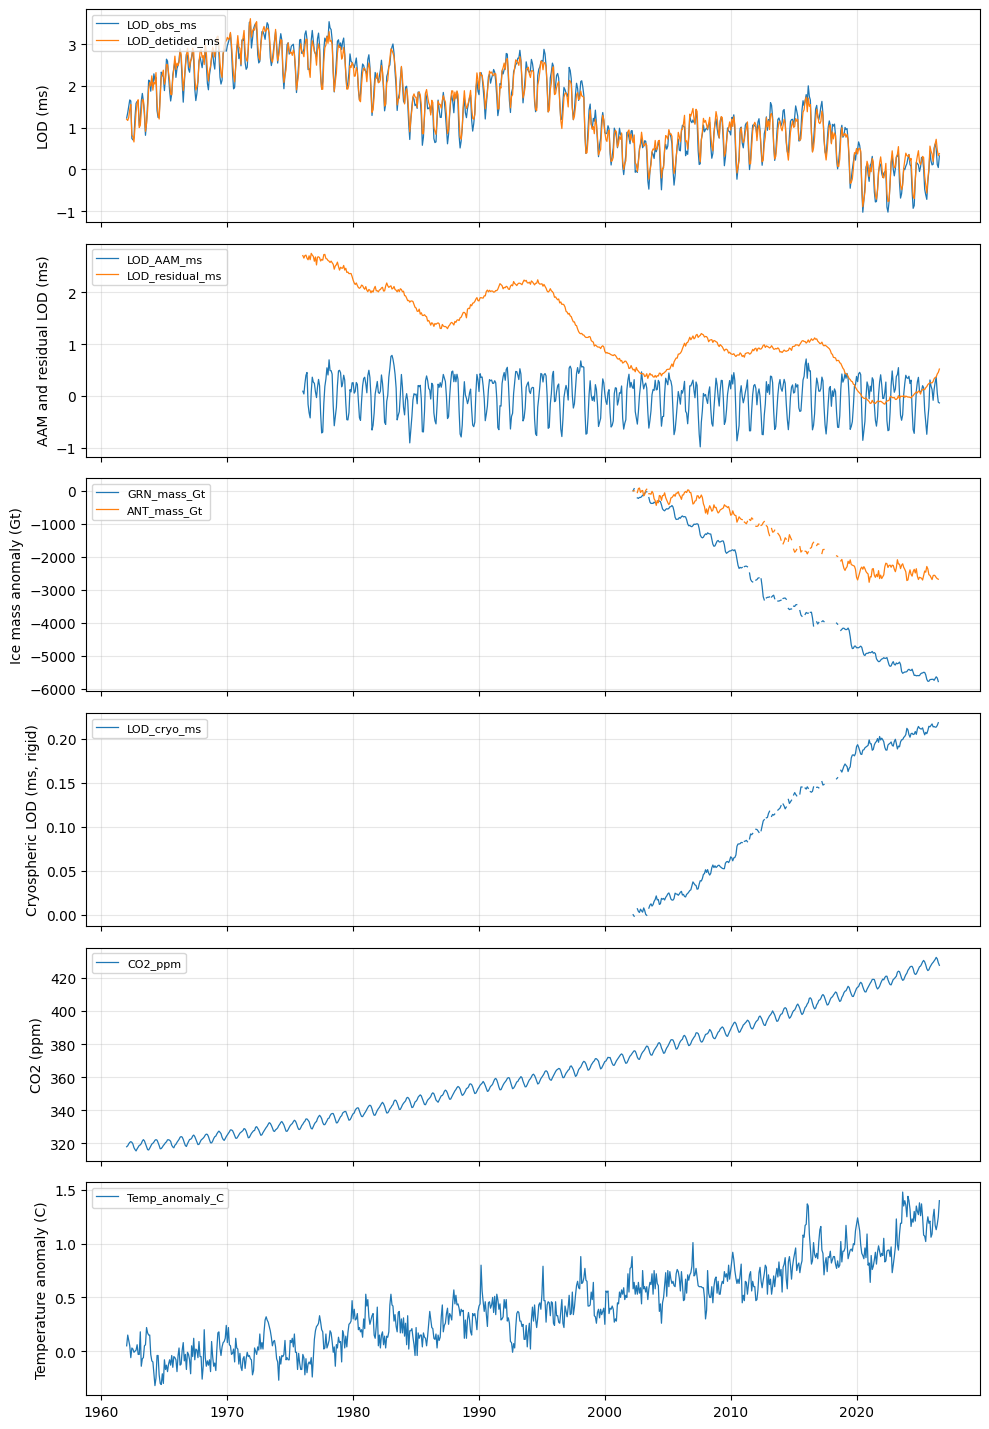

In [12]:
panels = [
    ("LOD (ms)", ["LOD_obs_ms", "LOD_detided_ms"]),
    ("AAM and residual LOD (ms)", ["LOD_AAM_ms", "LOD_residual_ms"]),
    ("Ice mass anomaly (Gt)", ["GRN_mass_Gt", "ANT_mass_Gt"]),
    ("Cryospheric LOD (ms, rigid)", ["LOD_cryo_ms"]),
    ("CO2 (ppm)", ["CO2_ppm"]),
    ("Temperature anomaly (C)", ["Temp_anomaly_C"]),
]
panels = [(t, [c for c in cs if df[c].notna().any()]) for t, cs in panels]
panels = [(t, cs) for t, cs in panels if cs]
fig, axes = plt.subplots(len(panels), 1, figsize=(10, 2.4 * len(panels)), sharex=True)
axes = np.atleast_1d(axes)
for ax, (title, cs) in zip(axes, panels):
    for c in cs:
        ax.plot(df.index, df[c], lw=0.9, label=c)
    ax.set_ylabel(title); ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()